# Kernel Density Estimation

KDE stima la densità dei dati normali posizionando un kernel gaussiano su ogni punto di training. Un nuovo punto è considerato anomalo se la sua log-likelihood sotto il modello è inferiore a una soglia, fissata al 5° percentile degli score di training (corrispondente a un tasso di falsi positivi del 5%). Il bandwidth è fissato a 0.5, valore ragionevole per dati normalizzati con StandardScaler.

Per ogni file il modello viene addestrato sulla parte normale (`anomaly==0`) e valutato sull'intera sequenza. La metrica è il **ritardo di primo rilevamento**: il numero di timestep tra l'inizio dell'anomalia e il primo allarme del modello.

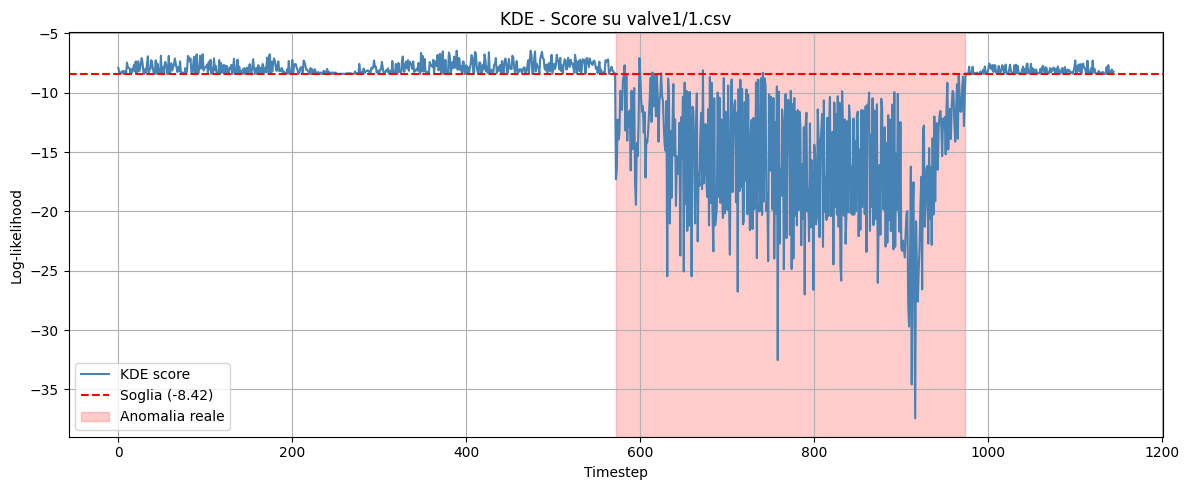

In [10]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import os
from sklearn.neighbors import KernelDensity
from sklearn.preprocessing import StandardScaler

with open("preprocessing.pkl", "rb") as f:
    prep = pickle.load(f)

features = prep["features"]
all_files = prep["all_files"]

def train_and_evaluate_kde(fpath, features, bw=0.5):
    df = pd.read_csv(fpath, sep=";")
    df_normal = df[df["anomaly"] == 0]
    
    scaler = StandardScaler()
    X_train = scaler.fit_transform(df_normal[features].values)
    
    kde = KernelDensity(kernel="gaussian", bandwidth=bw)
    kde.fit(X_train)
    
    scores_train = kde.score_samples(X_train)
    threshold = np.percentile(scores_train, 5)
    
    X_all = scaler.transform(df[features].values)
    scores_all = kde.score_samples(X_all)
    
    first_real = df[df["anomaly"] == 1].index[0]
    detections = np.where(scores_all < threshold)[0]
    detections_after = detections[detections >= first_real]
    
    if len(detections_after) > 0:
        first_detected = detections_after[0]
        delay = first_detected - first_real
    else:
        first_detected = None
        delay = None
    
    return {
        "first_real": first_real,
        "first_detected": first_detected,
        "delay": delay,
        "scores": scores_all,
        "threshold": threshold,
        "df": df
    }

# Visualizzazione su valve1/1.csv
result = train_and_evaluate_kde(all_files[1], features)

plt.figure(figsize=(12, 5))
plt.plot(result["scores"], color="steelblue", label="KDE score")
plt.axhline(y=result["threshold"], color="red", linestyle="--",
            label=f"Soglia ({result['threshold']:.2f})")
anomaly_idx = result["df"][result["df"]["anomaly"] == 1].index
plt.axvspan(anomaly_idx[0], anomaly_idx[-1], alpha=0.2, color="red", label="Anomalia reale")
plt.xlabel("Timestep")
plt.ylabel("Log-likelihood")
plt.title("KDE - Score su valve1/1.csv")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Risultati su tutti i file

In [11]:
results_kde = []

for fpath in all_files:
    res = train_and_evaluate_kde(fpath, features)
    folder = fpath.split("/")[-2]
    fname = fpath.split("/")[-1]
    results_kde.append({
        "file": f"{folder}/{fname}",
        "folder": folder,
        "first_real": res["first_real"],
        "first_detected": res["first_detected"],
        "delay": res["delay"]
    })

df_results_kde = pd.DataFrame(results_kde)
print(df_results_kde[["file", "delay"]])
print(f"\nRitardo medio: {df_results_kde['delay'].mean():.1f} timestep")
print(f"Non rilevati: {df_results_kde['delay'].isna().sum()}")

             file  delay
0    valve1/0.csv      0
1    valve1/1.csv      0
2   valve1/10.csv      0
3   valve1/11.csv      0
4   valve1/12.csv      0
5   valve1/13.csv      0
6   valve1/14.csv      0
7   valve1/15.csv      0
8    valve1/2.csv      0
9    valve1/3.csv      0
10   valve1/4.csv      0
11   valve1/5.csv      0
12   valve1/6.csv      0
13   valve1/7.csv      0
14   valve1/8.csv      0
15   valve1/9.csv      0
16   valve2/0.csv      0
17   valve2/1.csv      0
18   valve2/2.csv      0
19   valve2/3.csv      0
20    other/1.csv      0
21   other/10.csv      0
22   other/11.csv      1
23   other/12.csv      0
24   other/13.csv      1
25   other/14.csv     15
26    other/2.csv      0
27    other/3.csv      0
28    other/4.csv      0
29    other/5.csv      0
30    other/6.csv      0
31    other/7.csv      0
32    other/8.csv      1
33    other/9.csv      0

Ritardo medio: 0.5 timestep
Non rilevati: 0


## Visualizzazione dei ritardi

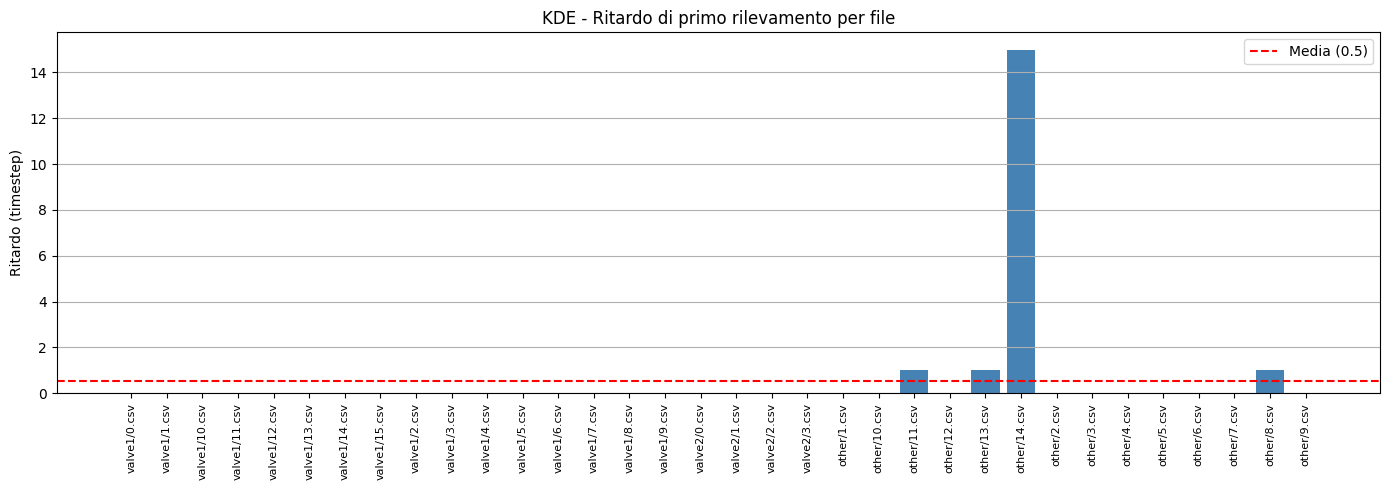

In [12]:
plt.figure(figsize=(14, 5))
plt.bar(df_results_kde["file"], df_results_kde["delay"], color="steelblue")
plt.xticks(rotation=90, fontsize=8)
plt.ylabel("Ritardo (timestep)")
plt.title("KDE - Ritardo di primo rilevamento per file")
plt.axhline(y=df_results_kde["delay"].mean(), color="red", linestyle="--", 
            label=f"Media ({df_results_kde['delay'].mean():.1f})")
plt.legend()
plt.grid(axis="y")
plt.tight_layout()
plt.show()